## STEP 1: Import Required Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Model utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

## STEP 2: Load Dataset

In [3]:
# Load the dataset
data = pd.read_csv("insurance_fraud_data_cleaned.csv")

# Separate features and target
X = data.iloc[:, :-1]   # Independent variables
y = data.iloc[:, -1]    # Target variable (Fraud / Non-Fraud)

## STEP 3: Train–Test Split

In [4]:
# Split the data into 80% training and 20% testing
# Stratify maintains class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## STEP 4: Train Models

In [5]:
# Define models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),           # Feature scaling
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train each model
for model in models.values():
    model.fit(X_train, y_train)

## STEP 5: Predictions & Probabilities

In [6]:
# Store predictions and probabilities
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

## GRAPH 1: CONFUSION MATRIX

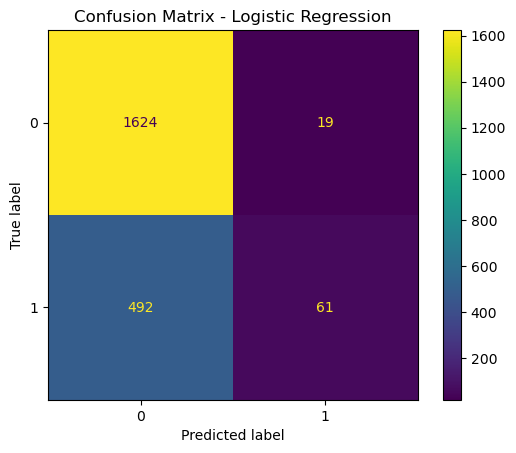

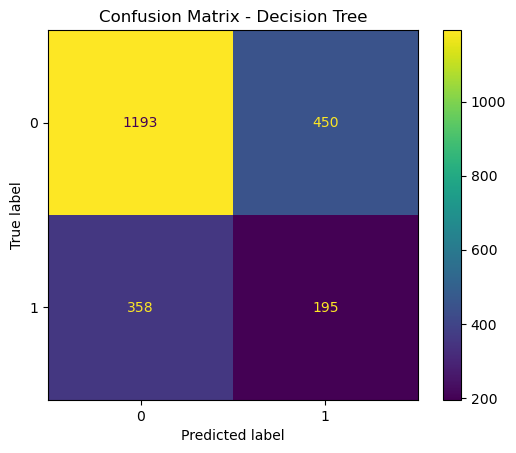

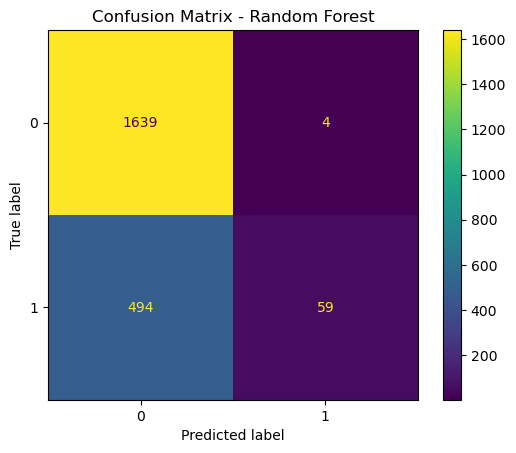

In [7]:
for name in predictions:
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

## GRAPH 2: ROC CURVE

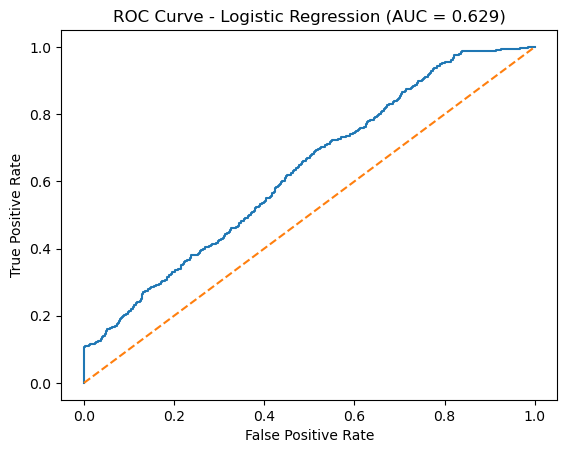

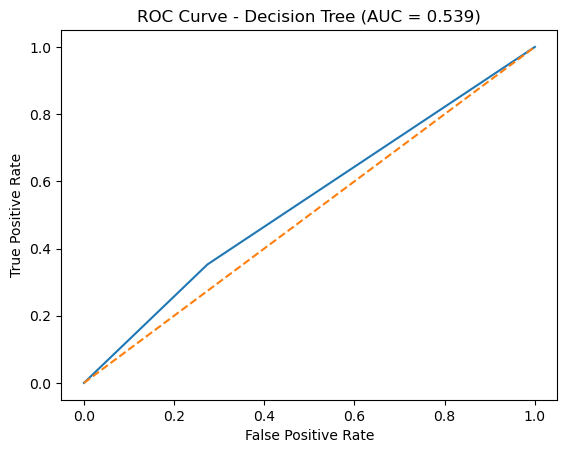

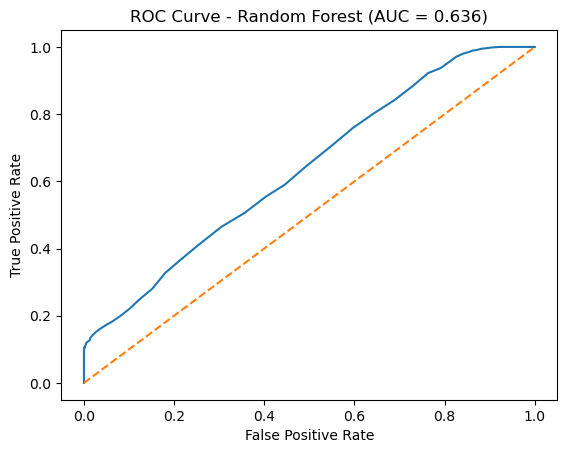

In [8]:
for name in probabilities:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name} (AUC = {auc:.3f})")
    plt.show()

## GRAPH 3: PRECISION–RECALL CURVE

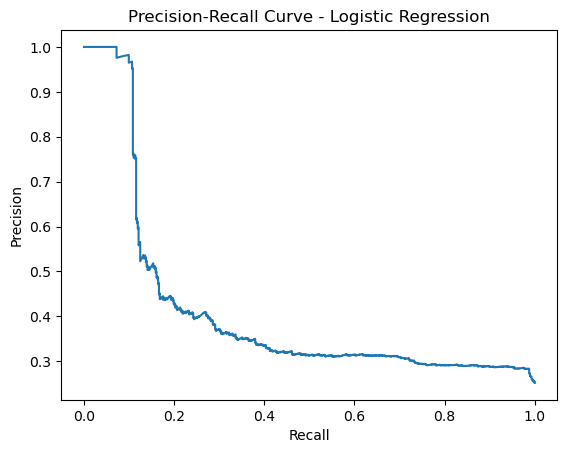

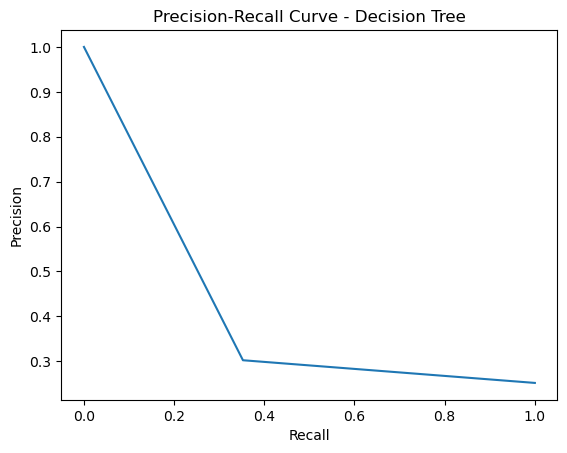

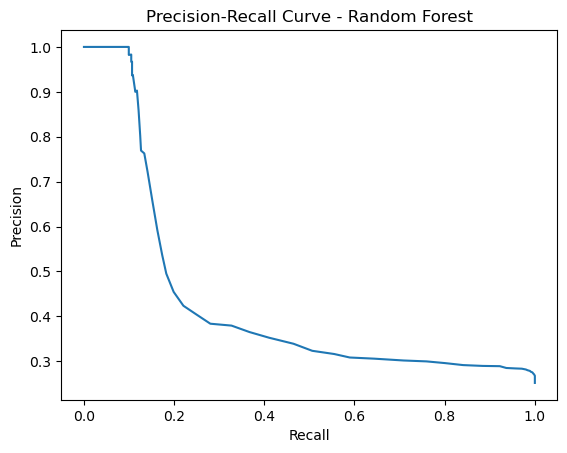

In [9]:
for name in probabilities:
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.show()

## GRAPH 4: METRIC COMPARISON BAR GRAPH

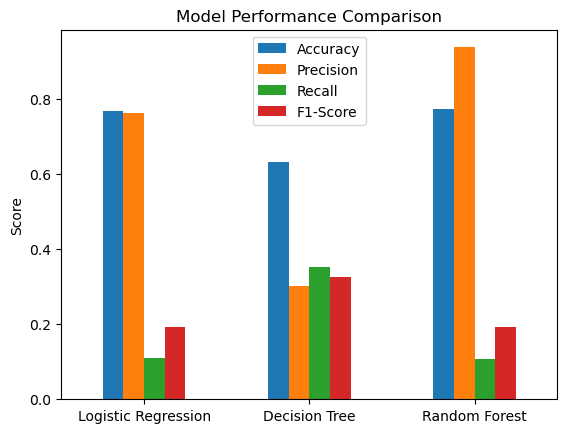

In [10]:
# Create a DataFrame to store metrics
metrics_df = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1-Score"])

# Calculate metrics for each model
for name in predictions:
    metrics_df.loc[name] = [
        accuracy_score(y_test, predictions[name]),
        precision_score(y_test, predictions[name]),
        recall_score(y_test, predictions[name]),
        f1_score(y_test, predictions[name])
    ]

# Plot bar graph
metrics_df.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

2. What is ROC Curve?
✅ Definition

ROC (Receiver Operating Characteristic) curve is a graph that shows the trade-off between:

True Positive Rate (TPR / Recall)

False Positive Rate (FPR)

at different classification thresholds.

❓ Why ROC is Used

Measures performance independent of threshold

Helps compare classifiers

Works well for binary classification

📊 Axes Explanation
Axis	Meaning
X-axis	False Positive Rate (FPR)
Y-axis	True Positive Rate (TPR / Recall)
📈 Interpretation

Curve closer to top-left corner → better model

Diagonal line → random classifier

3. What is ROC-AUC?
✅ Definition

ROC-AUC is the area under the ROC curve and represents the overall ability of the model to distinguish between classes.

📐 AUC Value Meaning
AUC Value	Interpretation
1.0	Perfect classifier
0.9 – 1.0	Excellent
0.7 – 0.9	Good
0.5	Random guessing
< 0.5	Worse than random
❓ Why ROC-AUC is Important

Single numeric value

Threshold-independent

Robust for imbalanced datasets